In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
# n_customers = 1000

# # Generate synthetic data with built-in correlations
# def generate_correlated_customer_data():
#     # Create base dataframe with customer IDs
#     df = pd.DataFrame({
#         'Customer_ID': [f'CUST{i:05d}' for i in range(1, n_customers + 1)],
#         'Age': np.random.randint(18, 71, n_customers)
#     })
    
#     # Location with realistic distribution
#     locations = np.random.choice(['Urban', 'Suburban', 'Rural'], n_customers, p=[0.6, 0.3, 0.1])
#     df['Location'] = locations
    
#     # Income level - correlated with age and location
#     df['Income_Level'] = pd.cut(
#         df['Age'] * (0.8 + 0.4 * np.random.random(n_customers)) + 
#         (locations == 'Urban') * 30 - (locations == 'Rural') * 10,
#         bins=[0, 30, 60, 100],
#         labels=['Low', 'Middle', 'High']
#     )
    
#     # Create base activity metrics
#     # Let's create a correlation: higher income → more transactions
#     income_factor = pd.factorize(df['Income_Level'], sort=True)[0] + 1
#     df['Total_Transactions'] = np.random.randint(1, 10, n_customers) * income_factor * 2
    
#     # Average transaction - correlated with income
#     df['Avg_Transaction_Value'] = np.abs(100 * (income_factor + np.random.normal(5, 0.5, n_customers)))

#     df['Avg_Transaction_Value'] = np.where(df['Total_Transactions']==0,0,df['Avg_Transaction_Value'])
    
#     # Total spent - perfectly correlated with previous metrics
#     df['Total_Spent'] = df['Total_Transactions'] * df['Avg_Transaction_Value']
    
#     # Active days - correlated with total transactions
#     df['Active_Days'] = np.int64(df['Total_Transactions'] * (5 + np.random.randint(1, 10, n_customers))+1)
    
#     # Recent activity - customers with higher transaction counts tend to be more recent shoppers
#     df['Last_Transaction_Days_Ago'] = np.int64(np.maximum(1, 30 - np.log(df['Total_Transactions']+.001) * 5 + np.random.randint(0, 15, n_customers)))
    
#     # Loyalty points - strongly correlated with total spent
#     df['Loyalty_Points_Earned'] = np.int64(df['Total_Spent'] * 0.05 * (0.8 + 0.4 * np.random.random(n_customers)))
    
#     # Referrals - somewhat correlated with satisfaction and income
#     df['Referral_Count'] = np.int64(np.random.poisson(income_factor * 0.3, n_customers))
    
#     # Cashback - correlated with total spent
#     df['Cashback_Received'] = np.abs(df['Total_Spent'] * 0.02 * (0.7 + 0.6 * np.random.random(n_customers)))
    
#     # App usage - correlated with transactions and age (inverse)
#     usage_score = df['Total_Transactions'] / df['Age']
#     usage_bins = pd.qcut(usage_score, 3, labels=['Monthly', 'Weekly', 'Daily'])
#     df['App_Usage_Frequency'] = usage_bins
    
#     # Payment methods - vary by demographics
#     payment_options = ['UPI', 'Credit Card', 'Debit Card', 'Wallet', 'Net Banking']
#     # Urban and higher income more likely to use credit cards
#     cc_prob = (0.1 + 0.2 * (df['Location'] == 'Urban') + 0.1 * (df['Income_Level'] == 'High')).values
#     upi_prob = (0.2 + 0.1 * (df['Location'] == 'Rural') + 0.1 * (df['Age'] < 30)).values
    
#     payment_probs = []
#     for i in range(n_customers):
#         probs = [upi_prob[i], cc_prob[i], 0.2, 0.15, 0.1]
#         # Normalize to sum to 1
#         probs = [p/sum(probs) for p in probs]
#         payment_probs.append(probs)
    
#     payment_methods = [np.random.choice(payment_options, p=probs) for probs in payment_probs]
#     df['Preferred_Payment_Method'] = payment_methods
    
#     # Support tickets - negative correlation with satisfaction
#     df['Support_Tickets_Raised'] = np.abs(np.int64(np.random.poisson(2, n_customers)))
    
#     # Resolution time - slight correlation with income (higher income, faster resolution)
#     base_resolution = np.random.exponential(5, n_customers)
#     income_adj = (3 - pd.factorize(df['Income_Level'], sort=True)[0]) * 0.5
#     df['Issue_Resolution_Time'] = np.maximum(1, base_resolution + income_adj) * df['Support_Tickets_Raised']
    
#     # Satisfaction - correlated negatively with support tickets and resolution time
#     satisfaction_base = 10 - df['Support_Tickets_Raised'] * 0.5 - df['Issue_Resolution_Time'] * 0.1
#     df['Customer_Satisfaction_Score'] = np.round(np.clip(satisfaction_base + np.random.normal(0, 1, n_customers), 1, 10))

#     df['Customer_Acquisition_Cost'] = np.abs(income_factor*np.random.normal(0,1,n_customers)) * np.random.randint(500,2500,n_customers)
    
#     # Calculate LTV based on a formula that creates clear correlationss
#     # LTV strongly correlates with total spent, active days, satisfaction, and negatively with last transaction days
#     df['LTV'] = (
#         df['Total_Spent'] * 1.2 + 
#         df['Active_Days'] * 10 + 
#         df['Total_Transactions'] * 50 -
#         df['Last_Transaction_Days_Ago'] * 30 +
#         df['Customer_Satisfaction_Score'] * 2000 +
#         np.random.normal(0, 500, n_customers)  # Add some noise
#     )
#     df['LTV'] = np.round(np.maximum(df['LTV'], 500))
    
#     return df

# # Generate the dataset
# customer_df = generate_correlated_customer_data()
# customer_df.to_csv('data/fintech_data.csv')

In [2]:
customer_df = pd.read_csv('data/fintech_data.csv')

In [3]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   1000 non-null   int64  
 1   Customer_ID                  1000 non-null   object 
 2   Age                          1000 non-null   int64  
 3   Location                     1000 non-null   object 
 4   Income_Level                 963 non-null    object 
 5   Total_Transactions           1000 non-null   int64  
 6   Avg_Transaction_Value        1000 non-null   float64
 7   Total_Spent                  1000 non-null   float64
 8   Active_Days                  1000 non-null   int64  
 9   Last_Transaction_Days_Ago    1000 non-null   int64  
 10  Loyalty_Points_Earned        1000 non-null   int64  
 11  Referral_Count               1000 non-null   int64  
 12  Cashback_Received            1000 non-null   float64
 13  App_Usage_Frequency

## NULLs y Outliers

### Primer punto: Retirar NULLs

In [4]:
mode_income_level = customer_df['Income_Level'].mode()[0]

In [5]:
customer_df['Income_Level'] = customer_df['Income_Level'].fillna(mode_income_level)

In [6]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   1000 non-null   int64  
 1   Customer_ID                  1000 non-null   object 
 2   Age                          1000 non-null   int64  
 3   Location                     1000 non-null   object 
 4   Income_Level                 1000 non-null   object 
 5   Total_Transactions           1000 non-null   int64  
 6   Avg_Transaction_Value        1000 non-null   float64
 7   Total_Spent                  1000 non-null   float64
 8   Active_Days                  1000 non-null   int64  
 9   Last_Transaction_Days_Ago    1000 non-null   int64  
 10  Loyalty_Points_Earned        1000 non-null   int64  
 11  Referral_Count               1000 non-null   int64  
 12  Cashback_Received            1000 non-null   float64
 13  App_Usage_Frequency

In [7]:
customer_df.describe()

,Unnamed: 0,Age,Total_Transactions,Avg_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,Customer_Acquisition_Cost,LTV
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,44.027000,22.504000,712.949457,17102.736231,225.334000,24.00900,857.849000,0.751000,340.958473,1.993000,11.582661,7.756000,2870.165694,38679.391000
std,288.819436,15.522668,14.816664,163.074172,12023.259846,164.520587,10.94032,613.976266,0.901005,252.241990,1.411007,14.479504,2.023996,2649.675586,17696.324494
min,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,10.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2663.000000
25%,249.750000,30.000000,12.000000,670.533001,6864.050546,97.000000,18.00000,344.750000,0.000000,130.255250,1.000000,2.674993,7.000000,834.415398,24598.000000
50%,499.500000,44.000000,20.000000,745.431629,14685.354328,193.000000,22.00000,751.500000,1.000000,292.058368,2.000000,6.748209,8.000000,2053.313135,35988.500000
75%,749.250000,58.000000,32.000000,802.039059,25095.954873,325.000000,27.00000,1244.250000,1.000000,495.288062,3.000000,14.265989,9.000000,4343.082643,50358.000000
max,999.000000,70.000000,54.000000,963.284337,49295.049022,757.000000,78.00000,2798.000000,6.000000,1168.888919,8.000000,98.558966,10.000000,14214.554570,84711.000000


In [8]:
customer_df = customer_df.drop(columns="Unnamed: 0")

### Segundo punto: Calcular LTV / CAC

In [9]:
customer_df['ltv_cac'] = customer_df['LTV'] / customer_df['Customer_Acquisition_Cost']

### Tercer punto: Hacer grupos por edad

In [10]:
customer_df['age_groups'] = pd.cut(customer_df['Age'], bins=[17,31,41,61,71], labels=["Joven","Adulto","Adulto Mayor","Senior"])

### Cuarto punto: Primer approach de análisis

<Axes: xlabel='Income_Level', ylabel='ltv_cac'>

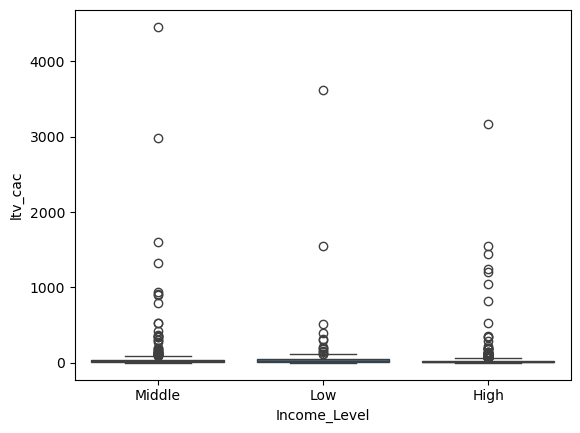

In [11]:
sns.boxplot(data=customer_df, x="Income_Level",y="ltv_cac")

<Axes: xlabel='age_groups', ylabel='ltv_cac'>

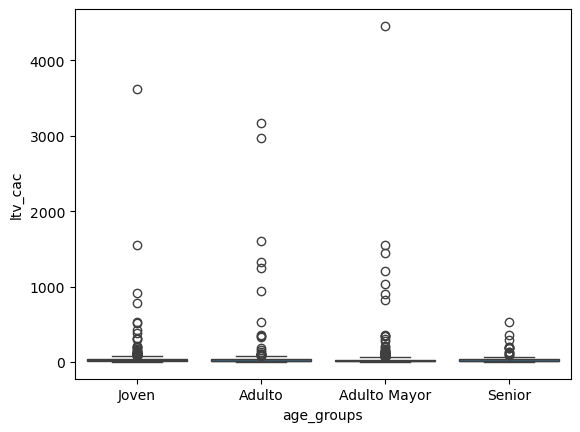

In [12]:
sns.boxplot(data=customer_df, x="age_groups",y="ltv_cac")

### Quinto punto: Retirar Outliers

In [13]:
p25 = customer_df['ltv_cac'].quantile(0.25)
p75 = customer_df['ltv_cac'].quantile(0.75)

iqr = (p75 - p25) 

lower_bound = p25-(iqr*3)
upper_bound = p75+(iqr*3)

customer_df['ltv_cac_outlier'] = ((customer_df['ltv_cac'] < lower_bound) | (customer_df['ltv_cac'] > upper_bound))*1

### Sexto punto: Calcular Outliers

In [14]:
customer_df['ltv_cac_outlier'].sum()

91

### Séptimo punto: Retirar Outliers

In [15]:
customer_df_no_outliers = customer_df[customer_df['ltv_cac_outlier'] == 0]

In [16]:
customer_df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Customer_ID                  909 non-null    object  
 1   Age                          909 non-null    int64   
 2   Location                     909 non-null    object  
 3   Income_Level                 909 non-null    object  
 4   Total_Transactions           909 non-null    int64   
 5   Avg_Transaction_Value        909 non-null    float64 
 6   Total_Spent                  909 non-null    float64 
 7   Active_Days                  909 non-null    int64   
 8   Last_Transaction_Days_Ago    909 non-null    int64   
 9   Loyalty_Points_Earned        909 non-null    int64   
 10  Referral_Count               909 non-null    int64   
 11  Cashback_Received            909 non-null    float64 
 12  App_Usage_Frequency          909 non-null    object  
 13  Preferred_

### Octavo Punto: Análisis sin Outliers

<Axes: xlabel='Income_Level', ylabel='ltv_cac'>

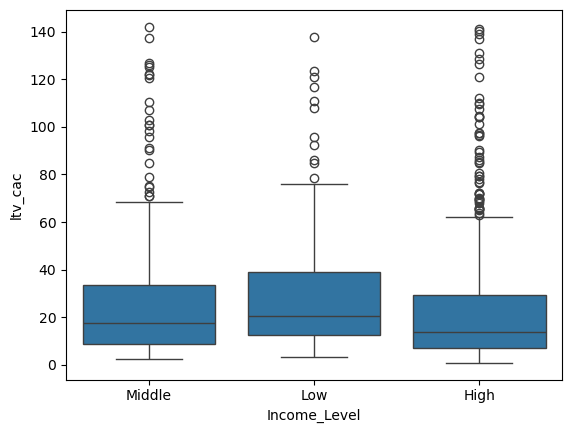

In [17]:
sns.boxplot(data=customer_df_no_outliers, x="Income_Level",y="ltv_cac")

<Axes: xlabel='age_groups', ylabel='ltv_cac'>

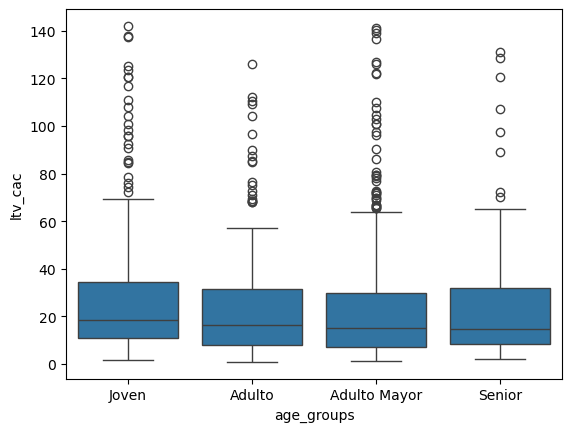

In [18]:
sns.boxplot(data=customer_df_no_outliers, x="age_groups",y="ltv_cac")

<Axes: xlabel='Location', ylabel='ltv_cac'>

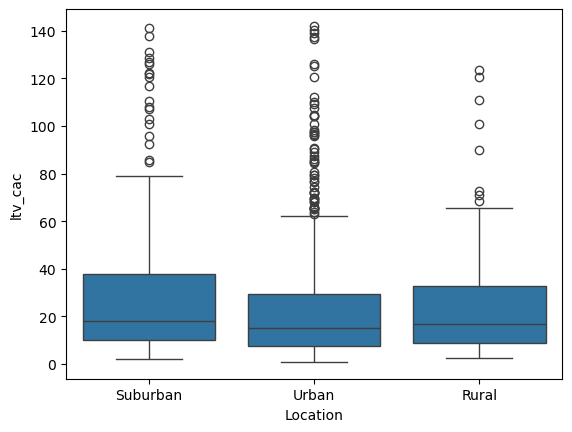

In [19]:
sns.boxplot(data=customer_df_no_outliers, x="Location",y="ltv_cac")

In [20]:
customer_df_no_outliers.groupby('Income_Level')['Customer_Acquisition_Cost'].median()

Income_Level
High      3265.965067
Low       1057.753303
Middle    1926.512475
Name: Customer_Acquisition_Cost, dtype: float64

### EXTRA: Correlation matrix

<Axes: >

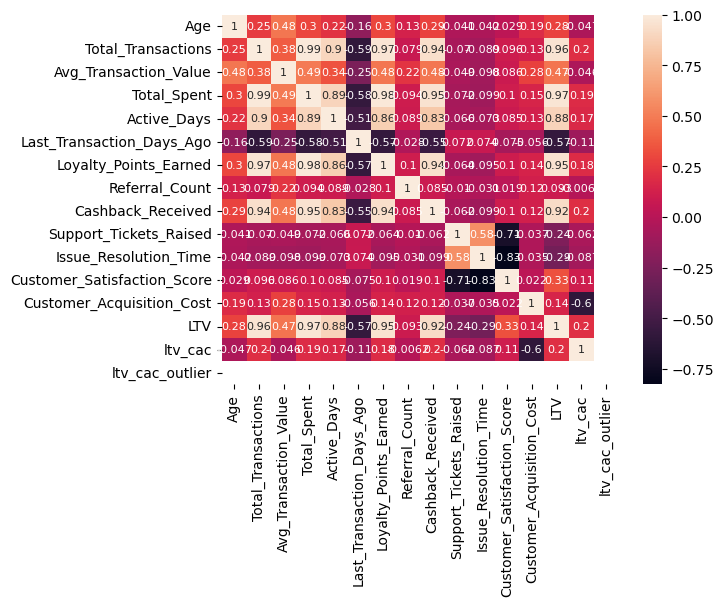

In [21]:
# Visualize correlations
correlation_matrix = customer_df_no_outliers.select_dtypes(include=[np.number]).corr()

sns.heatmap(correlation_matrix, annot=True, annot_kws={"size":8})

In [73]:
correlation_matrix

,Age,Total_Transactions,Avg_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,Customer_Acquisition_Cost,LTV,ltv_cac,ltv_cac_outlier
Age,1.000000,0.251933,0.476411,0.296090,0.218328,-0.163628,0.299552,0.130815,0.286084,-0.041081,-0.041626,0.029305,0.185251,0.281158,-0.047333,NaN
Total_Transactions,0.251933,1.000000,0.378063,0.988124,0.897643,-0.589437,0.967905,0.079449,0.937574,-0.069781,-0.088933,0.096384,0.129811,0.961445,0.195614,NaN
Avg_Transaction_Value,0.476411,0.378063,1.000000,0.487156,0.339075,-0.253374,0.477449,0.223516,0.479179,-0.048501,-0.097766,0.086257,0.279284,0.468119,-0.045639,NaN
Total_Spent,0.296090,0.988124,0.487156,1.000000,0.885999,-0.575692,0.980230,0.094216,0.952861,-0.071527,-0.098967,0.102935,0.149730,0.970827,0.186518,NaN
Active_Days,0.218328,0.897643,0.339075,0.885999,1.000000,-0.505817,0.864426,0.089429,0.830030,-0.065734,-0.072692,0.084963,0.127717,0.879256,0.167277,NaN
Last_Transaction_Days_Ago,-0.163628,-0.589437,-0.253374,-0.575692,-0.505817,1.000000,-0.573182,-0.027508,-0.546709,0.071916,0.074246,-0.075309,-0.056081,-0.571208,-0.106357,NaN
Loyalty_Points_Earned,0.299552,0.967905,0.477449,0.980230,0.864426,-0.573182,1.000000,0.102411,0.936562,-0.063729,-0.094612,0.100243,0.137664,0.951138,0.182466,NaN
Referral_Count,0.130815,0.079449,0.223516,0.094216,0.089429,-0.027508,0.102411,1.000000,0.084715,-0.010261,-0.031041,0.018526,0.117052,0.092639,-0.006213,NaN
Cashback_Received,0.286084,0.937574,0.479179,0.952861,0.830030,-0.546709,0.936562,0.084715,1.000000,-0.062277,-0.099017,0.103482,0.120854,0.924817,0.198387,NaN
Support_Tickets_Raised,-0.041081,-0.069781,-0.048501,-0.071527,-0.065734,0.071916,-0.063729,-0.010261,-0.062277,1.000000,0.577595,-0.709596,-0.036538,-0.236562,-0.062494,NaN
